## Computer Vision - Assignment 2

For this assignment I will be using the following agricultural crops image classification dataset:
https://www.kaggle.com/datasets/mdwaquarazam/agricultural-crops-image-classification/code

In [23]:
# pip install opencv-python

In [24]:
# pip install tensorflow

### Task 1: Load and preprocess the given dataset

In [25]:
# importing necessary libraries 
import os
import pandas as pd

# getting classes and assigning its id (starting from 0)
classes = os.listdir('Agricultural-crops')
mylist = enumerate(classes)

elements = []
for class_id in mylist:
    elements.append(class_id[0])
    
# saving the result into dataset
class_df = pd.DataFrame({'class_name':classes, 'class_id':elements})
class_df.head()

,class_name,class_id
0,almond,0
1,banana,1
2,cardamom,2
3,Cherry,3
4,chilli,4


In [26]:
# counting number of classes in total

print('The total number of classes in the dataset: ', len(classes))

The total number of classes in the dataset:  30


In [27]:
# counting the number of elements in each corresponding class 
                  
number_of_elements = [len(os.listdir('Agricultural-crops/' + x)) for x in classes]

# saving the result into dataset
class_df = pd.DataFrame({'class_name' : classes, 'number_of_elements' : number_of_elements})
class_df

,class_name,number_of_elements
0,almond,21
1,banana,31
2,cardamom,22
3,Cherry,32
4,chilli,23
5,clove,30
6,coconut,25
7,Coffee-plant,29
8,cotton,32
9,Cucumber,31


In [28]:
# getting total number of elements 

print('The total number of elements: ', class_df['number_of_elements'].sum())

The total number of elements:  829


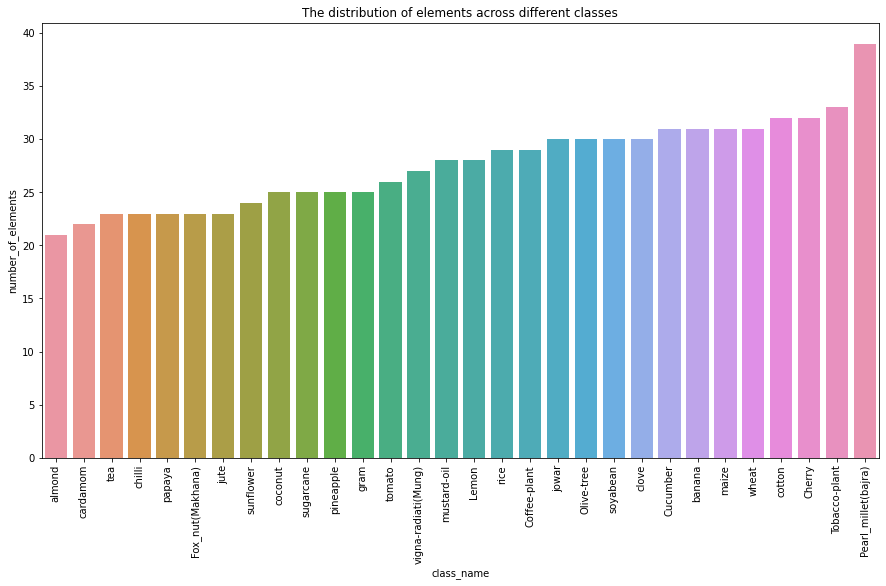

In [29]:
# visualization using seaborn and matplotlib libraries
import seaborn as sns
import matplotlib.pyplot as plt

class_df_sorted = class_df.sort_values('number_of_elements') # the dataset is sorted in ascending order for better visualization

plt.figure(figsize = (15,8))
sns.barplot(x = class_df_sorted['class_name'], y = class_df_sorted['number_of_elements'])
plt.xticks(rotation=90)
plt.title('The distribution of elements across different classes')
plt.show()

As can be seen from the plot above, the lowest number of elements is in the 'almond' class (21), while the highest number of elements is in the 'Pearl_millet(bajra)' class (39). 

(100, 100, 3)


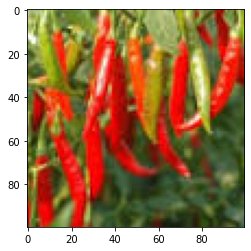

In [30]:
# for example visualizing one of the images and getting its resolution

img = plt.imread("Agricultural-crops/chilli/image.jpeg")
print(img.shape)
plt.imshow(img)

### Task 2: Implement a CNN with proper architecture (Fully Connected Layers, Convolution Layers, Pooling Layers etc.). Describe your implementation and explain why you choose such architecture.

As for this task, I decided to choose the GoogleNetv3 architecture also known as InceptionV3. Since it is a deep learning model which is based on CNN, it is widely used for image classification. Moreover, the architecture seems convenient for the given dataset as it takes an input 3-channel RGD images. By looking at the sample image shown above, I realized that the usage of this architecture can be applied for the model training. 

The material is taken from this source: https://pytorch.org/hub/pytorch_vision_inception_v3/

In [31]:
from keras.preprocessing.image import ImageDataGenerator as ImgDataGen

# splitting into train and valid sets

train = ImgDataGen(rescale=1/255, validation_split=0.1).flow_from_directory('Agricultural-crops', class_mode='binary', shuffle=True, target_size=(256,256), subset='training')
validation = ImgDataGen(rescale=1/255, validation_split=0.1).flow_from_directory('Agricultural-crops', class_mode='binary', shuffle=True, target_size=(256,256), subset='validation')

Found 757 images belonging to 30 classes.
Found 72 images belonging to 30 classes.


In [77]:
from tensorflow.keras.applications import InceptionV3
from keras.models import Sequential
from keras.layers import GlobalAvgPool2D as GAP, Dense, Dropout
from keras.callbacks import EarlyStopping, ModelCheckpoint

model_training = InceptionV3(include_top=False, input_shape=(256,256,3))
model_training.trainable = False

In [78]:
# building a model
model = Sequential([model_training, GAP(), Dense(len(classes))])

In [79]:
# compiling a model
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [80]:
# training a model, getting the accuracies for each epoch 
history = model.fit(train, validation_data=validation, epochs=10)

Epoch 1/10
24/24 [==============================] - 103s 4s/step - loss: 13.7768 - accuracy: 0.0304 - val_loss: 13.9687 - val_accuracy: 0.0278
Epoch 2/10
24/24 [==============================] - 89s 4s/step - loss: 13.6930 - accuracy: 0.0343 - val_loss: 14.1520 - val_accuracy: 0.0278
Epoch 3/10
24/24 [==============================] - 89s 4s/step - loss: 13.5528 - accuracy: 0.0383 - val_loss: 14.5910 - val_accuracy: 0.0278
Epoch 4/10
24/24 [==============================] - 89s 4s/step - loss: 13.3426 - accuracy: 0.0449 - val_loss: 13.5204 - val_accuracy: 0.0278
Epoch 5/10
24/24 [==============================] - 89s 4s/step - loss: 13.1019 - accuracy: 0.0370 - val_loss: 13.6789 - val_accuracy: 0.0278
Epoch 6/10
24/24 [==============================] - 88s 4s/step - loss: 13.0308 - accuracy: 0.0370 - val_loss: 14.3134 - val_accuracy: 0.0417
Epoch 7/10
24/24 [==============================] - 89s 4s/step - loss: 13.2488 - accuracy: 0.0634 - val_loss: 13.8204 - val_accuracy: 0.0417
Epoch

As can be seen from the accuracy score above, by getting №10 epoch the accuracy becomes quite high, i.e. scoring 0.945.

In [83]:
accuracy = model.evaluate(validation)

print('Acc.: %.2f%%' %(accuracy[1]*100))

Acc.: 72.21%


### Task 3:  Implement various architectures with different activations functions (Sigmoid, ReLU, Leaky ReLU, ELU). Describe your implementation for each activation function.

Two activation functions were used with the previously obtained architecture:

    1. Softmax. It is used since it is a good option when it comes to multi-class classification problems. Also, it accelerates the training time.

    2. ReLU. It helps reduce the pressure and get only the positive data to the model. 

In [68]:
# using ReLU activation function
model = Sequential([model_training, GAP(), Dense(len(classes), activation='softmax')])

# compiling a model
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# training a model, getting the accuracies for each epoch 
history = model.fit(train, validation_data=validation, epochs=10)

Epoch 1/10
24/24 [==============================] - 101s 4s/step - loss: 3.0035 - accuracy: 0.2021 - val_loss: 2.3390 - val_accuracy: 0.4583
Epoch 2/10
24/24 [==============================] - 87s 4s/step - loss: 1.6335 - accuracy: 0.6380 - val_loss: 1.8182 - val_accuracy: 0.5417
Epoch 3/10
24/24 [==============================] - 88s 4s/step - loss: 1.0850 - accuracy: 0.7873 - val_loss: 1.5343 - val_accuracy: 0.6389
Epoch 4/10
24/24 [==============================] - 89s 4s/step - loss: 0.7830 - accuracy: 0.8666 - val_loss: 1.3936 - val_accuracy: 0.6806
Epoch 5/10
24/24 [==============================] - 88s 4s/step - loss: 0.6037 - accuracy: 0.9036 - val_loss: 1.2794 - val_accuracy: 0.7083
Epoch 6/10
24/24 [==============================] - 88s 4s/step - loss: 0.4894 - accuracy: 0.9353 - val_loss: 1.2222 - val_accuracy: 0.7083
Epoch 7/10
24/24 [==============================] - 88s 4s/step - loss: 0.3908 - accuracy: 0.9564 - val_loss: 1.1788 - val_accuracy: 0.7361
Epoch 8/10
24/24 [=

In [69]:
# getting accuracy score
accuracy_softmax = model.evaluate(validation)
print('Acc.: %.2f%%' %(accuracy_softmax[1]*100))

3/3 [==============================] - 8s 2s/step - loss: 1.0613 - accuracy: 0.7083
Acc.: 70.83%


In [70]:
# using ReLU activation function
model = Sequential([model_training, GAP(), Dense(len(classes), activation='relu')])

# compiling a model
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# training a model, getting the accuracies for each epoch 
history = model.fit(train, validation_data=validation, epochs=10)

Epoch 1/10
24/24 [==============================] - 101s 4s/step - loss: 6.4315 - accuracy: 0.0634 - val_loss: 3.3540 - val_accuracy: 0.0556
Epoch 2/10
24/24 [==============================] - 88s 4s/step - loss: 3.3787 - accuracy: 0.0449 - val_loss: 3.3540 - val_accuracy: 0.0556
Epoch 3/10
24/24 [==============================] - 89s 4s/step - loss: 3.3787 - accuracy: 0.0449 - val_loss: 3.3540 - val_accuracy: 0.0556
Epoch 4/10
24/24 [==============================] - 88s 4s/step - loss: 3.3787 - accuracy: 0.0449 - val_loss: 3.3540 - val_accuracy: 0.0556
Epoch 5/10
24/24 [==============================] - 89s 4s/step - loss: 3.3787 - accuracy: 0.0449 - val_loss: 3.3540 - val_accuracy: 0.0556
Epoch 6/10
24/24 [==============================] - 87s 4s/step - loss: 3.3787 - accuracy: 0.0449 - val_loss: 3.3540 - val_accuracy: 0.0556
Epoch 7/10
24/24 [==============================] - 87s 4s/step - loss: 3.3787 - accuracy: 0.0449 - val_loss: 3.3540 - val_accuracy: 0.0556
Epoch 8/10
24/24 [=

In [71]:
# getting accuracy score
accuracy_relu = model.evaluate(validation)
print('Acc.: %.2f%%' %(accuracy_relu[1]*100))

3/3 [==============================] - 8s 2s/step - loss: 3.3540 - accuracy: 0.0556
Acc.: 5.56%


Softmax activation accuracy has the same accuracy result as in task 2. However, ReLU does not really work with the given model as the accuracy is too low.

### Task 4: Initialize your weights with different methods (Small random numbers, Xavier, Kaiming/MSRA). Describe your implementation for each method.


Two weights were used with the previously obtained architecture:
    
    1. Xavier initialization (also known as Glorot Uniform). It works good for layers with softmax activation. The algorithm works such way that it draws samples from a truncated normal distribution that is centered on zero.

    2. He normal. By initializing weights this way, the running time and efficiency can be improved.

In [60]:
# using he_normal initialization
model = Sequential([model_training, GAP(), Dense(len(classes), kernel_initializer='he_normal', activation='softmax')])

# compiling a model
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# training a model, getting the accuracies for each epoch 
history = model.fit(train, validation_data=validation, epochs=10)

Epoch 1/10
24/24 [==============================] - 101s 4s/step - loss: 3.0041 - accuracy: 0.2285 - val_loss: 2.4328 - val_accuracy: 0.4167
Epoch 2/10
24/24 [==============================] - 87s 4s/step - loss: 1.6789 - accuracy: 0.6222 - val_loss: 1.8400 - val_accuracy: 0.5833
Epoch 3/10
24/24 [==============================] - 88s 4s/step - loss: 1.1015 - accuracy: 0.7675 - val_loss: 1.4984 - val_accuracy: 0.6111
Epoch 4/10
24/24 [==============================] - 87s 4s/step - loss: 0.8073 - accuracy: 0.8494 - val_loss: 1.3780 - val_accuracy: 0.7083
Epoch 5/10
24/24 [==============================] - 87s 4s/step - loss: 0.6225 - accuracy: 0.8996 - val_loss: 1.3231 - val_accuracy: 0.7361
Epoch 6/10
24/24 [==============================] - 87s 4s/step - loss: 0.4916 - accuracy: 0.9419 - val_loss: 1.2172 - val_accuracy: 0.7361
Epoch 7/10
24/24 [==============================] - 87s 4s/step - loss: 0.3989 - accuracy: 0.9590 - val_loss: 1.1852 - val_accuracy: 0.7361
Epoch 8/10
24/24 [=

In [61]:
# getting accuracy score
accuracy_he = model.evaluate(validation)
print('Acc.: %.2f%%' %(accuracy_he[1]*100))

3/3 [==============================] - 8s 2s/step - loss: 1.0819 - accuracy: 0.7639
Acc.: 76.39%


In [65]:
# using Xavier initialization
import tensorflow
from tensorflow.keras import initializers
 
initializer = tensorflow.keras.initializers.GlorotUniform()
model = Sequential([model_training, GAP(), Dense(len(classes), kernel_initializer=initializer, activation='softmax')])

# compiling a model
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# training a model, getting the accuracies for each epoch 
history = model.fit(train, validation_data=validation, epochs=10)

Epoch 1/10
24/24 [==============================] - 101s 4s/step - loss: 2.9250 - accuracy: 0.2048 - val_loss: 2.4829 - val_accuracy: 0.3056
Epoch 2/10
24/24 [==============================] - 88s 4s/step - loss: 1.6446 - accuracy: 0.6196 - val_loss: 1.8178 - val_accuracy: 0.5694
Epoch 3/10
24/24 [==============================] - 89s 4s/step - loss: 1.0867 - accuracy: 0.8071 - val_loss: 1.5881 - val_accuracy: 0.6250
Epoch 4/10
24/24 [==============================] - 87s 4s/step - loss: 0.8164 - accuracy: 0.8520 - val_loss: 1.3911 - val_accuracy: 0.6806
Epoch 5/10
24/24 [==============================] - 88s 4s/step - loss: 0.6237 - accuracy: 0.9036 - val_loss: 1.3633 - val_accuracy: 0.6528
Epoch 6/10
24/24 [==============================] - 88s 4s/step - loss: 0.5060 - accuracy: 0.9234 - val_loss: 1.2229 - val_accuracy: 0.6944
Epoch 7/10
24/24 [==============================] - 89s 4s/step - loss: 0.3981 - accuracy: 0.9524 - val_loss: 1.2375 - val_accuracy: 0.6806
Epoch 8/10
24/24 [=

In [66]:
# getting accuracy score
accuracy_xavier = model.evaluate(validation)
print('Acc.: %.2f%%' %(accuracy_xavier[1]*100))

3/3 [==============================] - 8s 2s/step - loss: 1.1143 - accuracy: 0.7361
Acc.: 73.61%


### Task 5: Apply different regularization methods (L1, L2, Dropout, Batch normalization). Describe your implementation for each method.

Two regularization methods were used with the previously obtained architecture:
    
    1. Dropout. The main reason of choosing this method is that Dropout helps prevent overfitting.
    
    2. Batch Normalization. This technique helps to normalize the input data and further decrease the pressure on the algorithm.
 

In [53]:
# using Dropout regularization
model = Sequential([model_training, GAP(), Dropout(.2), Dense(len(classes), activation='softmax')])

# compiling a model
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# training a model, getting the accuracies for each epoch 
history = model.fit(train, validation_data=validation, epochs=10)

Epoch 1/10
24/24 [==============================] - 132s 5s/step - loss: 3.0809 - accuracy: 0.1849 - val_loss: 2.3587 - val_accuracy: 0.4167
Epoch 2/10
24/24 [==============================] - 111s 5s/step - loss: 1.7757 - accuracy: 0.5416 - val_loss: 1.8100 - val_accuracy: 0.5833
Epoch 3/10
24/24 [==============================] - 110s 5s/step - loss: 1.2122 - accuracy: 0.7213 - val_loss: 1.5710 - val_accuracy: 0.5972
Epoch 4/10
24/24 [==============================] - 113s 5s/step - loss: 0.9004 - accuracy: 0.8151 - val_loss: 1.3591 - val_accuracy: 0.6944
Epoch 5/10
24/24 [==============================] - 114s 5s/step - loss: 0.7050 - accuracy: 0.8758 - val_loss: 1.3300 - val_accuracy: 0.6944
Epoch 6/10
24/24 [==============================] - 111s 5s/step - loss: 0.5844 - accuracy: 0.9075 - val_loss: 1.2328 - val_accuracy: 0.7222
Epoch 7/10
24/24 [==============================] - 109s 5s/step - loss: 0.4876 - accuracy: 0.9128 - val_loss: 1.1830 - val_accuracy: 0.6944
Epoch 8/10
24

In [54]:
# getting accuracy score
accuracy_dropout = model.evaluate(validation)
print('Acc.: %.2f%%' %(accuracy_dropout[1]*100))

3/3 [==============================] - 10s 3s/step - loss: 1.0858 - accuracy: 0.7361
Acc.: 73.61%


In [56]:
from tensorflow import keras

# using Batch Normalization
model = Sequential([model_training, GAP(), Dense(len(classes), activation='softmax')])
model.add(keras.layers.BatchNormalization())
# compiling a model
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# training a model, getting the accuracies for each epoch 
history = model.fit(train, validation_data=validation, epochs=10)

Epoch 1/10
24/24 [==============================] - 127s 5s/step - loss: 9.9050 - accuracy: 0.0779 - val_loss: 6.8401 - val_accuracy: 0.0417
Epoch 2/10
24/24 [==============================] - 113s 5s/step - loss: 6.8363 - accuracy: 0.2259 - val_loss: 6.1448 - val_accuracy: 0.0556
Epoch 3/10
24/24 [==============================] - 110s 5s/step - loss: 4.3496 - accuracy: 0.3937 - val_loss: 3.4536 - val_accuracy: 0.2083
Epoch 4/10
24/24 [==============================] - 108s 4s/step - loss: 2.8632 - accuracy: 0.5429 - val_loss: 3.2652 - val_accuracy: 0.2500
Epoch 5/10
24/24 [==============================] - 108s 4s/step - loss: 2.0944 - accuracy: 0.5627 - val_loss: 3.7424 - val_accuracy: 0.2778
Epoch 6/10
24/24 [==============================] - 110s 5s/step - loss: 2.0422 - accuracy: 0.5694 - val_loss: 4.4762 - val_accuracy: 0.2917
Epoch 7/10
24/24 [==============================] - 108s 4s/step - loss: 1.6943 - accuracy: 0.6116 - val_loss: 3.7468 - val_accuracy: 0.2639
Epoch 8/10
24

In [58]:
# getting accuracy score
accuracy_batch = model.evaluate(validation)
print('Acc.: %.2f%%' %(accuracy_batch[1]*100))

3/3 [==============================] - 8s 2s/step - loss: 3.7286 - accuracy: 0.3611
Acc.: 36.11%


### Task 6: Describe, compare, and visualize your results.

In [84]:
# creating dataframe to view the results 
d = {'Name': ['CNN', 'CNN+softmax', 'CNN+ReLU', 'CNN+Dropout', 'CNN+BatchNormalization', 'CNN+Xavier', 'CNN+HeNormal'], 'Accuracy': [accuracy, accuracy_softmax[1], accuracy_relu[1], accuracy_dropout[1], accuracy_batch[1], accuracy_xavier[1], accuracy_he[1]]}

df = pd.DataFrame(data=d)
df

,Name,Accuracy
0,CNN,0.722147
1,CNN+softmax,0.708333
2,CNN+ReLU,0.055556
3,CNN+Dropout,0.736111
4,CNN+BatchNormalization,0.361111
5,CNN+Xavier,0.736111
6,CNN+HeNormal,0.763889


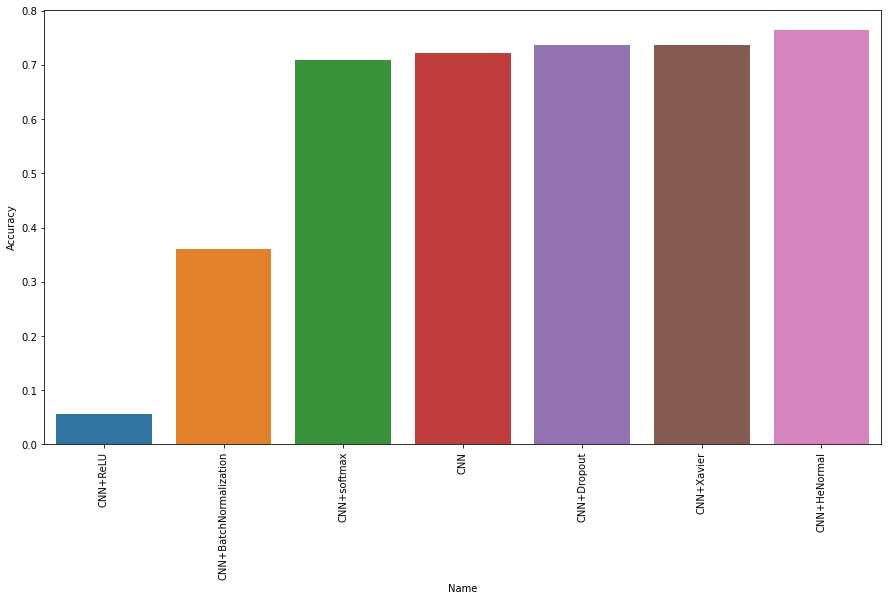

In [87]:
# visualization using seaborn and matplotlib libraries
import seaborn as sns
import matplotlib.pyplot as plt

df2 = df.sort_values('Accuracy') # the dataset is sorted in ascending order for better visualization


plt.figure(figsize = (15,8))
sns.barplot(x = df2['Name'], y = df2['Accuracy'])
plt.xticks(rotation=90)
plt.show()

From the results presented in the data frame above it can be concluded that by adding up some parameters, using activation functions, regularization or initialization techniques, the accuracy score of the model can be improved. To sum up, implementing CNN with CNN and He_Normal initialization gives the highest result in terms of accuracy score, while CNN with ReLU activation function decreases the performance.